In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet(
    "data_actually_clean/county_month_combined.parquet"
)

print(df.shape)
df.head()

(17541, 141)


,county,year_month,sales_dollars,sales_bottles,sales_liters,sales_gallons,avg_alcohol_level_g210L,num_tests,county_population,S2301_C01_001,...,S2301_C04_026,S2301_C04_027,S2301_C04_028,S2301_C04_029,S2301_C04_030,S2301_C04_031,S2301_C04_032,S2301_C04_033,S2301_C04_034,S2301_C04_035
0,ADAIR,2012-01,24967.11,2263,2165.94,572.06,0.124,24.0,7468.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ADAIR,2012-02,28078.87,2559,2569.06,678.40,0.124,24.0,7468.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ADAIR,2012-03,25380.59,2285,2197.89,580.46,0.124,24.0,7468.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ADAIR,2012-04,36608.04,3097,2915.09,769.73,0.124,24.0,7468.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ADAIR,2012-05,35782.93,3086,3055.53,806.78,0.124,24.0,7468.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing.sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
S2301_C01_017,17505,99.794767
S2301_C04_017,17505,99.794767
S2301_C02_017,17505,99.794767
S2301_C03_017,17505,99.794767
S2301_C03_015,17481,99.657944
...,...,...
sales_gallons,0,0.000000
sales_liters,0,0.000000
sales_bottles,0,0.000000
sales_dollars,0,0.000000


In [9]:
employment = pd.read_parquet(
    "external_data_clean/employment_status_for_iowa_civilian_population_16_years_old_and_over_acs_1_year_estimate_1188_rows.parquet"
)

employment.shape

(34560, 27)

In [10]:
emp_county = employment[
    employment["geography_type"] == "County"
].copy()

print("County employment rows:", len(emp_county))
print(
    "Unique counties:",
    emp_county["county_fips_code"].nunique()
)

print("\nCounties represented by year:")

print(
    emp_county
    .groupby("data_collection_period")
    ["county_fips_code"]
    .nunique()
)

County employment rows: 18600
Unique counties: 10

Counties represented by year:
data_collection_period
2010    10
2011    10
2012    10
2013    10
2014    10
2015    10
2016    10
2017    10
2018    10
2019    10
2021    10
2022    10
2023    10
2024    10
Name: county_fips_code, dtype: int64


In [11]:
#Only 10 counties are represented in the employment dataset
employment_cols = [
    col for col in df.columns
    if col.startswith("S2301_")
]

print("Employment columns:", len(employment_cols))

Employment columns: 132


In [12]:
df_main = df.drop(
    columns=employment_cols
).copy()

df_main.shape

(17541, 9)

We initially considered ACS 1-year employment estimates as predictors. Exploratory analysis showed that the dataset covered only 10 Iowa counties, which would exclude most counties from models requiring these variables. Because this missingness was systematically related to geographic coverage rather than random missing observations, we excluded these variables from our primary statewide models rather than dropping counties or imputing unsupported values.

In [13]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17541 entries, 0 to 17540
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   17541 non-null  object 
 1   year_month               17541 non-null  object 
 2   sales_dollars            17541 non-null  float64
 3   sales_bottles            17541 non-null  int64  
 4   sales_liters             17541 non-null  float64
 5   sales_gallons            17541 non-null  float64
 6   avg_alcohol_level_g210L  17399 non-null  float64
 7   num_tests                17399 non-null  float64
 8   county_population        15427 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 1.2+ MB


In [14]:
df_main.columns.tolist()

['county',
 'year_month',
 'sales_dollars',
 'sales_bottles',
 'sales_liters',
 'sales_gallons',
 'avg_alcohol_level_g210L',
 'num_tests',
 'county_population']

In [15]:
#Separate year and month
df_main["year_month"] = pd.to_datetime(
    df_main["year_month"]
)

df_main["year"] = df_main["year_month"].dt.year
df_main["month"] = df_main["year_month"].dt.month

In [16]:
#all counties represented
df_main.groupby("year").agg(
    rows=("county", "size"),
    counties=("county", "nunique")
)

,rows,counties
year,,
2012,1199,100
2013,1198,100
2014,1195,100
2015,1197,100
2016,1199,100
2017,1200,100
2018,1199,101
2019,1192,100
2020,1189,100


In [17]:
#Check for duplicates
duplicates = (
    df_main.groupby(["county", "year_month"])
      .size()
      .reset_index(name="count")
)

duplicates[
    duplicates["count"] > 1
]

,county,year_month,count


In [20]:
#Population not represented in 2025-2026
population_coverage = (
    df_main.groupby("year")
      .agg(
          counties=("county", "nunique"),
          counties_with_population=(
              "county_population",
              lambda x: x.notna().sum()
          )
      )
)

population_coverage

,counties,counties_with_population
year,,
2012,100,1187
2013,100,1186
2014,100,1183
2015,100,1186
2016,100,1187
2017,100,1188
2018,101,1188
2019,100,1184
2020,100,1186


In [21]:
#BAC represented in all rows
bac_coverage = (
    df_main.groupby("year")
      .agg(
          counties=("county", "nunique"),
          counties_with_population=(
              "avg_alcohol_level_g210L",
              lambda x: x.notna().sum()
          )
      )
)

bac_coverage

,counties,counties_with_population
year,,
2012,100,1187
2013,100,1186
2014,100,1183
2015,100,1186
2016,100,1187
2017,100,1188
2018,101,1188
2019,100,1184
2020,100,1186


In [22]:
booze = df_main[
    [
        "county",
        "year_month",
        "year",
        "month",
        "sales_dollars",
        "sales_bottles",
        "sales_liters",
        "sales_gallons",
        "county_population"
    ]
].copy()

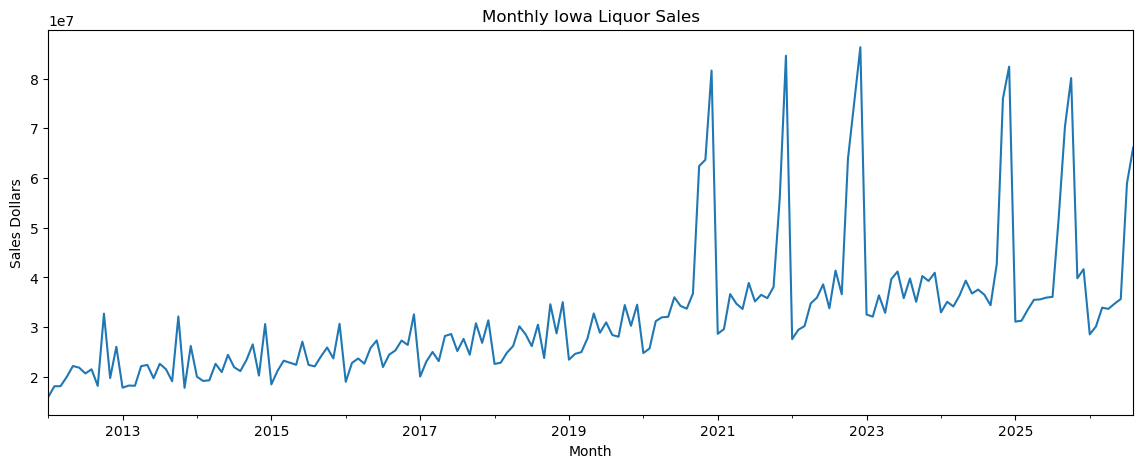

In [23]:
state_monthly = (
    booze.groupby("year_month")["sales_dollars"]
         .sum()
)

state_monthly.plot(
    figsize=(14, 5),
    title="Monthly Iowa Liquor Sales"
)

plt.ylabel("Sales Dollars")
plt.xlabel("Month")
plt.show()

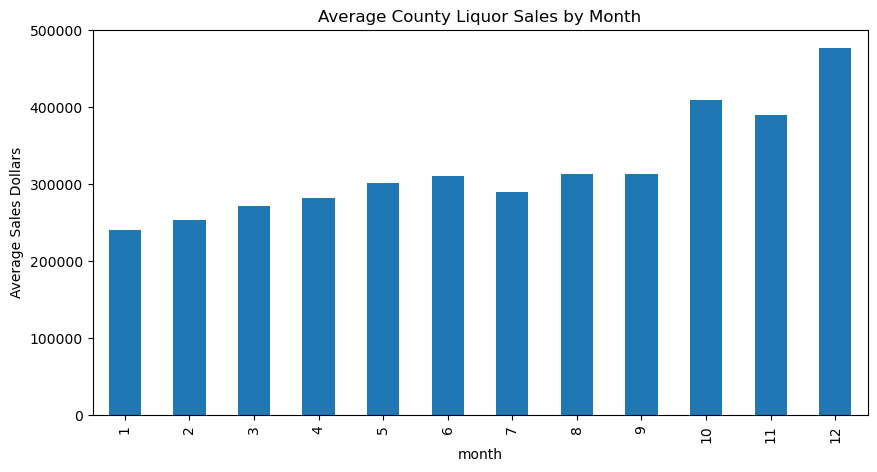

In [24]:
monthly_pattern = (
    booze[
        booze["year"] < 2026
    ]
    .groupby("month")["sales_dollars"]
    .mean()
)

monthly_pattern.plot(
    kind="bar",
    figsize=(10, 5),
    title="Average County Liquor Sales by Month"
)

plt.ylabel("Average Sales Dollars")
plt.show()

In [25]:
#Average monthly sales by county
county_avg = (
    booze.groupby("county")["sales_dollars"]
         .mean()
         .sort_values(ascending=False)
)

county_avg.head(15)

county
POLK             7.389746e+06
LINN             2.782284e+06
SCOTT            2.212532e+06
JOHNSON          1.887965e+06
BLACK HAWK       1.729035e+06
POTTAWATTAMIE    1.170590e+06
WOODBURY         1.110240e+06
STORY            9.459282e+05
DUBUQUE          9.421202e+05
DALLAS           8.271024e+05
CERRO GORDO      6.626937e+05
CLINTON          5.885837e+05
DICKINSON        4.384568e+05
DES MOINES       3.734121e+05
MARSHALL         3.688696e+05
Name: sales_dollars, dtype: float64

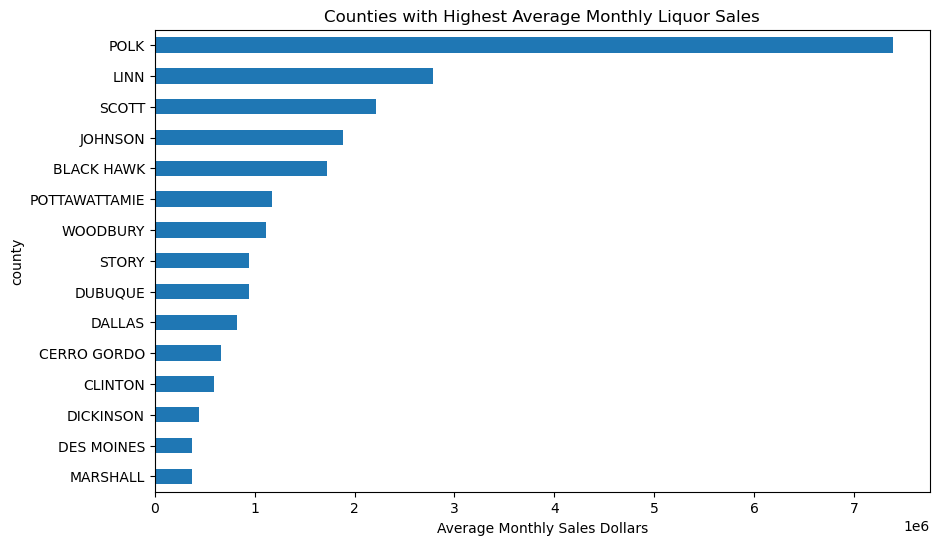

In [26]:
county_avg.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Counties with Highest Average Monthly Liquor Sales"
)

plt.xlabel("Average Monthly Sales Dollars")
plt.show()

In [27]:
booze["sales_dollars"].describe()

count    1.754100e+04
mean     3.247847e+05
std      9.308207e+05
min      3.114000e+01
25%      4.448466e+04
50%      9.370547e+04
75%      2.050809e+05
max      2.042934e+07
Name: sales_dollars, dtype: float64

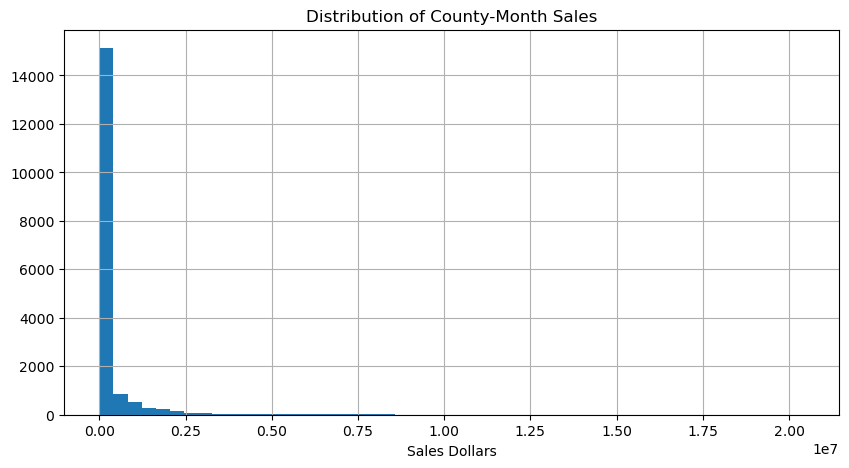

In [28]:
booze["sales_dollars"].hist(
    bins=50,
    figsize=(10, 5)
)

plt.title("Distribution of County-Month Sales")
plt.xlabel("Sales Dollars")
plt.show()

In [29]:
#New variables with county sales from: 1. Month before 2. Same month previous year 3. previous 3 month average 4. previous 12 month average

booze = booze.sort_values(
    ["county", "year_month"]
).reset_index(drop=True)

county_group = booze.groupby("county")

booze["sales_lag_1"] = (
    county_group["sales_dollars"]
    .shift(1)
)

booze["sales_lag_12"] = (
    county_group["sales_dollars"]
    .shift(12)
)

booze["sales_previous_3mo_avg"] = (
    county_group["sales_dollars"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)

booze["sales_previous_12mo_avg"] = (
    county_group["sales_dollars"]
    .transform(
        lambda x: x.shift(1).rolling(12).mean()
    )
)

In [30]:
booze[
    [
        "sales_dollars",
        "sales_lag_1",
        "sales_lag_12",
        "sales_previous_3mo_avg",
        "sales_previous_12mo_avg"
    ]
].corr()

,sales_dollars,sales_lag_1,sales_lag_12,sales_previous_3mo_avg,sales_previous_12mo_avg
sales_dollars,1.000000,0.936148,0.943303,0.930065,0.945115
sales_lag_1,0.936148,1.000000,0.918269,0.971697,0.950780
sales_lag_12,0.943303,0.918269,1.000000,0.932157,0.954556
sales_previous_3mo_avg,0.930065,0.971697,0.932157,1.000000,0.976419
sales_previous_12mo_avg,0.945115,0.950780,0.954556,0.976419,1.000000


In [31]:
#Create baseline prediction
booze_model = booze.dropna(
    subset=["sales_lag_12"]
).copy()

booze_model["baseline_prediction"] = (
    booze_model["sales_lag_12"]
)

In [32]:
#Error metrics
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(
        np.mean((y_true - y_pred) ** 2)
    )

def mae(y_true, y_pred):
    return np.mean(
        np.abs(y_true - y_pred)
    )

In [33]:
#3-fold split
train = booze_model[
    booze_model["year"] <= 2023
].copy()

validation = booze_model[
    booze_model["year"] == 2024
].copy()

test = booze_model[
    booze_model["year"] == 2025
].copy()

In [34]:
print(
    "Validation baseline RMSE:",
    rmse(
        validation["sales_dollars"],
        validation["baseline_prediction"]
    )
)

print(
    "Validation baseline MAE:",
    mae(
        validation["sales_dollars"],
        validation["baseline_prediction"]
    )
)

Validation baseline RMSE: 431433.501525452
Validation baseline MAE: 97695.170360134


In [35]:
#Booze Model

from sklearn.linear_model import LinearRegression

X_train = train[
    ["sales_lag_12"]
]

y_train = train["sales_dollars"]

X_val = validation[
    ["sales_lag_12"]
]

y_val = validation["sales_dollars"]

model1 = LinearRegression()

model1.fit(
    X_train,
    y_train
)

pred1 = model1.predict(X_val)

print("RMSE:", rmse(y_val, pred1))
print("MAE:", mae(y_val, pred1))

print("Intercept:", model1.intercept_)
print("Coefficient:", model1.coef_)

RMSE: 430878.02387102507
MAE: 98555.39303440168
Intercept: 15686.356689191132
Coefficient: [0.99615563]


In [36]:
#Better results may be caused due to multicollinearity

features2 = [
    "sales_lag_1",
    "sales_lag_12"
]

X_train = train[features2]
X_val = validation[features2]

model2 = LinearRegression()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_val)

print("RMSE:", rmse(y_val, pred2))
print("MAE:", mae(y_val, pred2))

RMSE: 344671.30311843765
MAE: 85404.21010445242


In [37]:
#Better results may be caused due to multicollinearity

features3 = [
    "sales_lag_1",
    "sales_lag_12",
    "sales_previous_3mo_avg",
    "sales_previous_12mo_avg"
]

model3 = LinearRegression()

model3.fit(
    train[features3],
    y_train
)

pred3 = model3.predict(
    validation[features3]
)

print("RMSE:", rmse(y_val, pred3))
print("MAE:", mae(y_val, pred3))

RMSE: 360610.5785725708
MAE: 87172.38780063466


In [38]:
#New model for seasonality

month_dummies = pd.get_dummies(
    booze_model["month"],
    prefix="month",
    drop_first=True,
    dtype=int
)

booze_model = pd.concat(
    [booze_model, month_dummies],
    axis=1
)

In [39]:
train = booze_model[
    booze_model["year"] <= 2023
].copy()

validation = booze_model[
    booze_model["year"] == 2024
].copy()

test = booze_model[
    booze_model["year"] == 2025
].copy()

In [40]:
month_features = [
    f"month_{i}"
    for i in range(2, 13)
]

features4 = [
    "sales_lag_1",
    "sales_lag_12",
] + month_features

model4 = LinearRegression()

model4.fit(
    train[features4],
    train["sales_dollars"]
)

pred4 = model4.predict(
    validation[features4]
)

print(
    "RMSE:",
    rmse(
        validation["sales_dollars"],
        pred4
    )
)

print(
    "MAE:",
    mae(
        validation["sales_dollars"],
        pred4
    )
)

RMSE: 340048.335426233
MAE: 88942.56029183186


In [41]:
results_booze = pd.DataFrame({
    "Model": [
        "Previous-year baseline",
        "Lag 12 regression",
        "Lag 1 + Lag 12",
        "Rolling history",
        "Lag 1 + Lag 12 + Month"
    ],

    "RMSE": [
        rmse(
            validation["sales_dollars"],
            validation["sales_lag_12"]
        ),
        rmse(validation["sales_dollars"], pred1),
        rmse(validation["sales_dollars"], pred2),
        rmse(validation["sales_dollars"], pred3),
        rmse(validation["sales_dollars"], pred4)
    ],

    "MAE": [
        mae(
            validation["sales_dollars"],
            validation["sales_lag_12"]
        ),
        mae(validation["sales_dollars"], pred1),
        mae(validation["sales_dollars"], pred2),
        mae(validation["sales_dollars"], pred3),
        mae(validation["sales_dollars"], pred4)
    ]
})

results_booze.sort_values("RMSE")

,Model,RMSE,MAE
4,Lag 1 + Lag 12 + Month,340048.335426,88942.560292
2,Lag 1 + Lag 12,344671.303118,85404.210104
3,Rolling history,360610.578573,87172.387801
1,Lag 12 regression,430878.023871,98555.393034
0,Previous-year baseline,431433.501525,97695.170360


In [42]:
final_features = [
    "sales_lag_1",
    "sales_lag_12"
] + month_features

print("Final features:")
print(final_features)
# Chosen based on RMSE

Final features:
['sales_lag_1', 'sales_lag_12', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']


In [43]:
#Retraining through 2024: 
train_final = booze_model[
    booze_model["year"] <= 2024
].copy()

test_final = booze_model[
    booze_model["year"] == 2025
].copy()

final_model = LinearRegression()

final_model.fit(
    train_final[final_features],
    train_final["sales_dollars"]
)

final_coefficients = pd.DataFrame({
    "feature": final_features,
    "coefficient": final_model.coef_
})

print("Intercept:")
print(final_model.intercept_)

final_coefficients

#Testing on 2025
test_final = test_final.copy()

test_final["predicted_sales"] = (
    final_model.predict(
        test_final[final_features]
    )
)

test_final["residual"] = (
    test_final["sales_dollars"]
    - test_final["predicted_sales"]
)

test_final["absolute_error"] = (
    test_final["residual"].abs()
)

#Performance: 
final_test_rmse = rmse(
    test_final["sales_dollars"],
    test_final["predicted_sales"]
)

final_test_mae = mae(
    test_final["sales_dollars"],
    test_final["predicted_sales"]
)

print(
    "Final 2025 Test RMSE:",
    round(final_test_rmse, 2)
)

print(
    "Final 2025 Test MAE:",
    round(final_test_mae, 2)
)

#Compared to baseline:
baseline_test_rmse = rmse(
    test_final["sales_dollars"],
    test_final["sales_lag_12"]
)

baseline_test_mae = mae(
    test_final["sales_dollars"],
    test_final["sales_lag_12"]
)

print(
    "2025 Baseline RMSE:",
    round(baseline_test_rmse, 2)
)

print(
    "2025 Final Model RMSE:",
    round(final_test_rmse, 2)
)

print()

print(
    "2025 Baseline MAE:",
    round(baseline_test_mae, 2)
)

print(
    "2025 Final Model MAE:",
    round(final_test_mae, 2)
)

#Improvement
rmse_improvement = (
    (baseline_test_rmse - final_test_rmse)
    / baseline_test_rmse
    * 100
)

mae_improvement = (
    (baseline_test_mae - final_test_mae)
    / baseline_test_mae
    * 100
)

print(
    "RMSE improvement over baseline:",
    round(rmse_improvement, 1),
    "%"
)

print(
    "MAE improvement over baseline:",
    round(mae_improvement, 1),
    "%"
)

Intercept:
-94880.83572443825
Final 2025 Test RMSE: 546058.74
Final 2025 Test MAE: 151386.96
2025 Baseline RMSE: 616508.92
2025 Final Model RMSE: 546058.74

2025 Baseline MAE: 161334.94
2025 Final Model MAE: 151386.96
RMSE improvement over baseline: 11.4 %
MAE improvement over baseline: 6.2 %


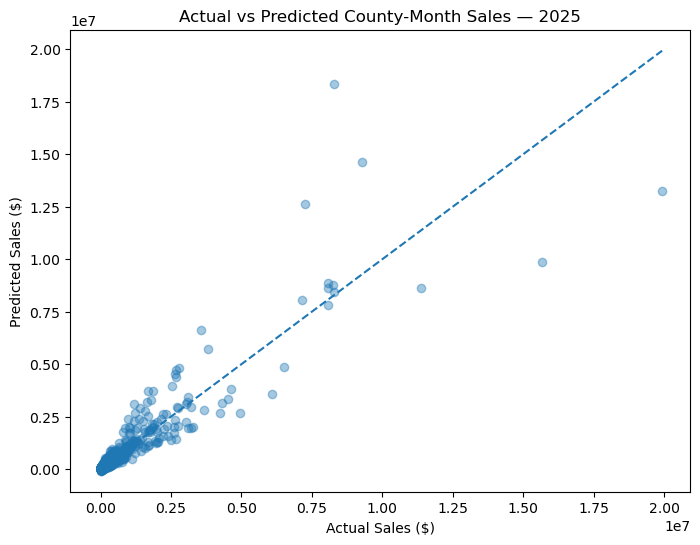

In [48]:
#Actual versus predicted 2025
plt.figure(figsize=(8, 6))

plt.scatter(
    test_final["sales_dollars"],
    test_final["predicted_sales"],
    alpha=0.4
)

minimum = min(
    test_final["sales_dollars"].min(),
    test_final["predicted_sales"].min()
)

maximum = max(
    test_final["sales_dollars"].max(),
    test_final["predicted_sales"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Sales ($)")
plt.ylabel("Predicted Sales ($)")
plt.title("Actual vs Predicted County-Month Sales — 2025")

plt.show()

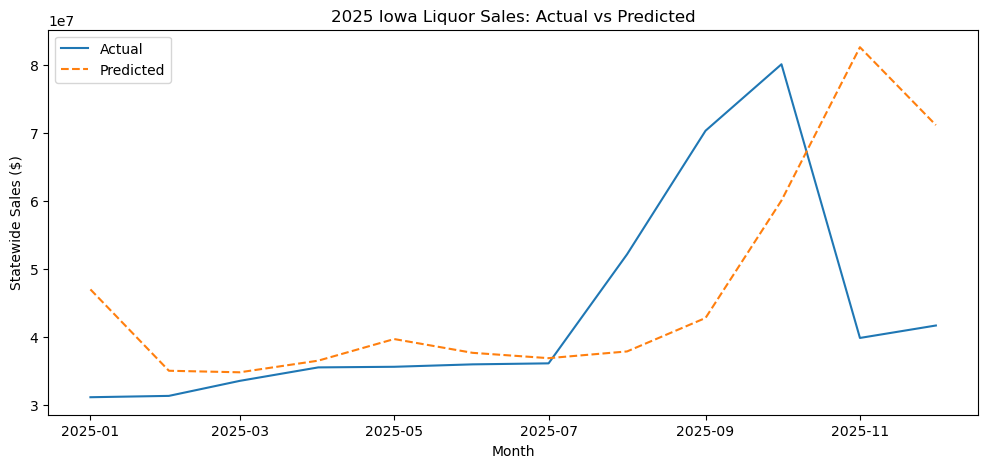

In [49]:
#By state
state_test = (
    test_final
    .groupby("year_month")
    .agg(
        actual_sales=("sales_dollars", "sum"),
        predicted_sales=("predicted_sales", "sum")
    )
    .reset_index()
)

state_test.head()

plt.figure(figsize=(12, 5))

plt.plot(
    state_test["year_month"],
    state_test["actual_sales"],
    label="Actual"
)

plt.plot(
    state_test["year_month"],
    state_test["predicted_sales"],
    label="Predicted",
    linestyle="--"
)

plt.xlabel("Month")
plt.ylabel("Statewide Sales ($)")
plt.title("2025 Iowa Liquor Sales: Actual vs Predicted")

plt.legend()

plt.show()

In [50]:
actual_2025 = (
    test_final["sales_dollars"].sum()
)

predicted_2025 = (
    test_final["predicted_sales"].sum()
)

total_error_pct = (
    (predicted_2025 - actual_2025)
    / actual_2025
    * 100
)

print(
    "Actual 2025 sales:",
    f"${actual_2025:,.0f}"
)

print(
    "Predicted 2025 sales:",
    f"${predicted_2025:,.0f}"
)

print(
    "Statewide prediction error:",
    f"{total_error_pct:.2f}%"
)

Actual 2025 sales: $523,110,954
Predicted 2025 sales: $561,834,018
Statewide prediction error: 7.40%


In [51]:
test_final[
    [
        "county",
        "year_month",
        "sales_dollars",
        "predicted_sales",
        "absolute_error"
    ]
].sort_values(
    "absolute_error",
    ascending=False
).head(20)

,county,year_month,sales_dollars,predicted_sales,absolute_error
13659,POLK,2025-11-01,8301332.00,1.833894e+07,1.003760e+07
13658,POLK,2025-10-01,19930763.88,1.326007e+07,6.670697e+06
13657,POLK,2025-09-01,15657748.26,9.847286e+06,5.810462e+06
13649,POLK,2025-01-01,7269994.56,1.264598e+07,5.375984e+06
13660,POLK,2025-12-01,9282797.00,1.463914e+07,5.356341e+06
10006,LINN,2025-11-01,3576437.00,6.623208e+06,3.046771e+06
13656,POLK,2025-08-01,11368302.78,8.647124e+06,2.721179e+06
10004,LINN,2025-09-01,6095065.00,3.565883e+06,2.529182e+06
14537,SCOTT,2025-09-01,4954519.38,2.659582e+06,2.294938e+06
9996,LINN,2025-01-01,2658756.37,4.740051e+06,2.081294e+06


In [52]:
test_final[
    [
        "county",
        "year_month",
        "sales_dollars",
        "predicted_sales",
        "absolute_error"
    ]
].sort_values(
    "absolute_error",
    ascending=False
).head(20)

,county,year_month,sales_dollars,predicted_sales,absolute_error
13659,POLK,2025-11-01,8301332.00,1.833894e+07,1.003760e+07
13658,POLK,2025-10-01,19930763.88,1.326007e+07,6.670697e+06
13657,POLK,2025-09-01,15657748.26,9.847286e+06,5.810462e+06
13649,POLK,2025-01-01,7269994.56,1.264598e+07,5.375984e+06
13660,POLK,2025-12-01,9282797.00,1.463914e+07,5.356341e+06
10006,LINN,2025-11-01,3576437.00,6.623208e+06,3.046771e+06
13656,POLK,2025-08-01,11368302.78,8.647124e+06,2.721179e+06
10004,LINN,2025-09-01,6095065.00,3.565883e+06,2.529182e+06
14537,SCOTT,2025-09-01,4954519.38,2.659582e+06,2.294938e+06
9996,LINN,2025-01-01,2658756.37,4.740051e+06,2.081294e+06


In [53]:
print(
    "Latest month in dataset:",
    booze["year_month"].max()
)

Latest month in dataset: 2026-08-01 00:00:00


In [54]:
forecast_history = (
    booze[
        booze["year"] <= 2025
    ][
        [
            "county",
            "year_month",
            "sales_dollars"
        ]
    ]
    .copy()
)

forecast_history = forecast_history.sort_values(
    ["county", "year_month"]
)

In [55]:
forecast_rows = []
for month in range(1, 13):

    forecast_date = pd.Timestamp(
        year=2026,
        month=month,
        day=1
    )

    for county in forecast_history["county"].unique():

        county_history = (
            forecast_history[
                forecast_history["county"] == county
            ]
            .sort_values("year_month")
        )

        # Previous month
        previous_month_date = (
            forecast_date
            - pd.DateOffset(months=1)
        )

        lag1_row = county_history[
            county_history["year_month"]
            == previous_month_date
        ]

        # Same month previous year
        previous_year_date = (
            forecast_date
            - pd.DateOffset(months=12)
        )

        lag12_row = county_history[
            county_history["year_month"]
            == previous_year_date
        ]

        if (
            len(lag1_row) == 0
            or len(lag12_row) == 0
        ):
            continue

        sales_lag_1 = (
            lag1_row["sales_dollars"].iloc[0]
        )

        sales_lag_12 = (
            lag12_row["sales_dollars"].iloc[0]
        )

        row = {
            "sales_lag_1": sales_lag_1,
            "sales_lag_12": sales_lag_12
        }

        # January is reference category
        for m in range(2, 13):
            row[f"month_{m}"] = (
                1 if month == m else 0
            )

        X_forecast = pd.DataFrame(
            [row]
        )[final_features]

        prediction = (
            final_model.predict(
                X_forecast
            )[0]
        )

        # Prevent impossible negative sales
        prediction = max(
            prediction,
            0
        )

        forecast_rows.append({
            "county": county,
            "year_month": forecast_date,
            "predicted_sales": prediction
        })

        # Add prediction back into history
        # so February can use January forecast,
        # March can use February forecast, etc.
        new_history_row = pd.DataFrame({
            "county": [county],
            "year_month": [forecast_date],
            "sales_dollars": [prediction]
        })

        forecast_history = pd.concat(
            [
                forecast_history,
                new_history_row
            ],
            ignore_index=True
        )

In [56]:
forecast_2026 = pd.DataFrame(
    forecast_rows
)

forecast_2026.head()

,county,year_month,predicted_sales
0,ADAIR,2026-01-01,0.0
1,ADAMS,2026-01-01,0.0
2,ALLAMAKEE,2026-01-01,0.0
3,APPANOOSE,2026-01-01,0.0
4,AUDUBON,2026-01-01,0.0


In [59]:
projected_2026_sales = (
    forecast_2026["predicted_sales"].sum()
)

print(
    "Projected 2026 Iowa liquor sales:",
    f"${projected_2026_sales:,.0f}"
)
sales_2025 = (
    booze[
        booze["year"] == 2025
    ]["sales_dollars"].sum()
)

projected_growth = (
    (projected_2026_sales - sales_2025)
    / sales_2025
    * 100
)

print(
    "2025 sales:",
    f"${sales_2025:,.0f}"
)

print(
    "Projected 2026 sales:",
    f"${projected_2026_sales:,.0f}"
)

print(
    "Projected growth:",
    f"{projected_growth:.1f}%"
)

Projected 2026 Iowa liquor sales: $548,898,348
2025 sales: $523,110,954
Projected 2026 sales: $548,898,348
Projected growth: 4.9%


In [61]:
historical_state = (
    booze[
        booze["year"] <= 2025
    ]
    .groupby("year_month")["sales_dollars"]
    .sum()
    .reset_index()
)

In [62]:
forecast_state = (
    forecast_2026
    .groupby("year_month")["predicted_sales"]
    .sum()
    .reset_index()
)

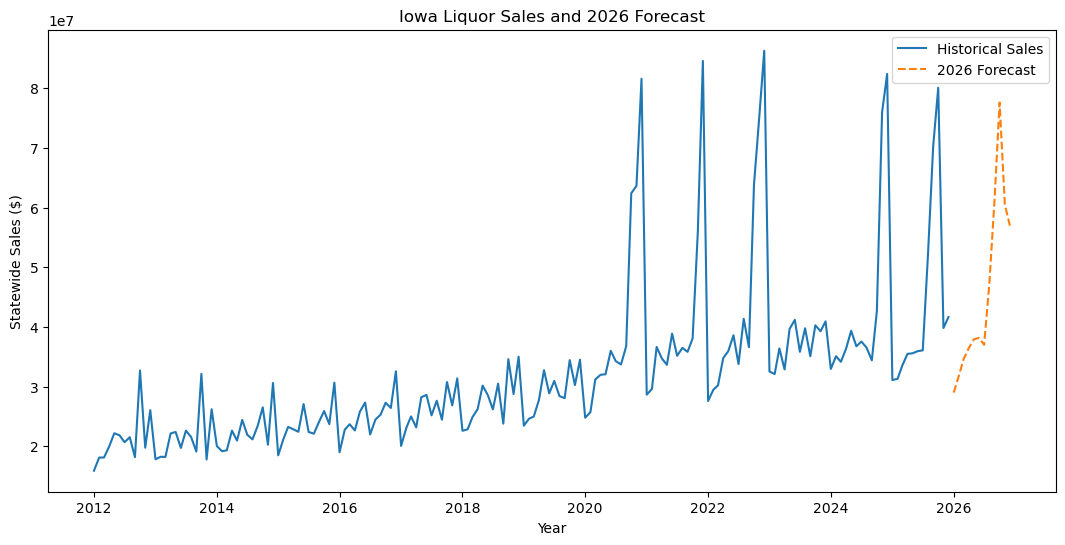

In [63]:
plt.figure(figsize=(13, 6))

plt.plot(
    historical_state["year_month"],
    historical_state["sales_dollars"],
    label="Historical Sales"
)

plt.plot(
    forecast_state["year_month"],
    forecast_state["predicted_sales"],
    label="2026 Forecast",
    linestyle="--"
)

plt.xlabel("Year")
plt.ylabel("Statewide Sales ($)")
plt.title("Iowa Liquor Sales and 2026 Forecast")

plt.legend()

plt.show()

In [64]:
forecast_monthly = (
    forecast_2026
    .groupby(
        forecast_2026["year_month"].dt.month
    )["predicted_sales"]
    .sum()
    .reset_index()
)

forecast_monthly.columns = [
    "month",
    "predicted_sales"
]

forecast_monthly[
    "month_name"
] = pd.to_datetime(
    forecast_monthly["month"],
    format="%m"
).dt.month_name()

forecast_monthly.sort_values(
    "predicted_sales",
    ascending=False
)

,month,predicted_sales,month_name
9,10,7.762136e+07,October
8,9,6.134266e+07,September
10,11,6.056408e+07,November
11,12,5.696946e+07,December
7,8,4.729084e+07,August
5,6,3.817631e+07,June
4,5,3.793232e+07,May
6,7,3.701835e+07,July
3,4,3.648166e+07,April
2,3,3.463554e+07,March


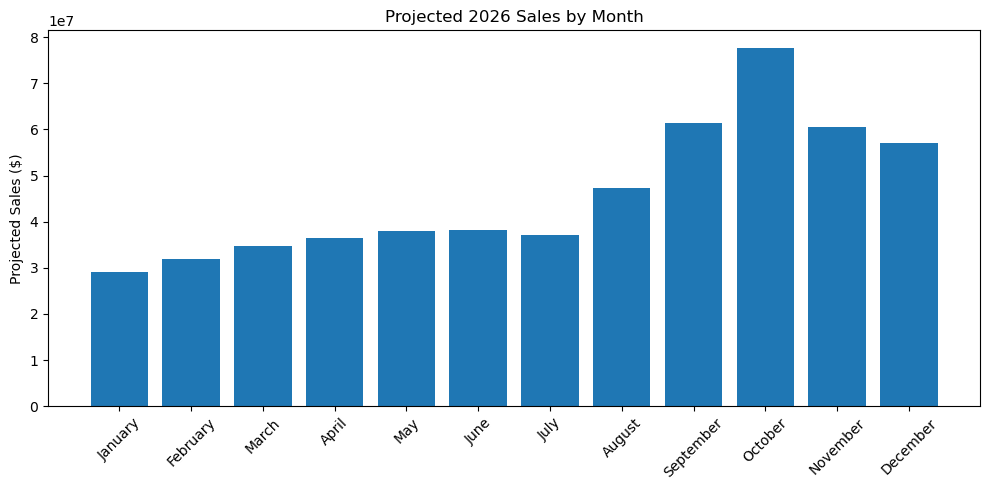

In [65]:
plt.figure(figsize=(10, 5))

plt.bar(
    forecast_monthly["month_name"],
    forecast_monthly["predicted_sales"]
)

plt.xticks(rotation=45)

plt.ylabel("Projected Sales ($)")
plt.title("Projected 2026 Sales by Month")

plt.tight_layout()

plt.show()

In [66]:
county_forecast = (
    forecast_2026
    .groupby("county")["predicted_sales"]
    .sum()
    .sort_values(ascending=False)
)

county_forecast.head(15)

county
POLK             1.248824e+08
LINN             4.676767e+07
SCOTT            3.486748e+07
JOHNSON          3.155690e+07
BLACK HAWK       2.532886e+07
POTTAWATTAMIE    2.042311e+07
WOODBURY         1.862694e+07
DALLAS           1.855960e+07
DUBUQUE          1.571309e+07
STORY            1.518968e+07
CLINTON          1.378147e+07
CERRO GORDO      1.066267e+07
DICKINSON        7.394967e+06
MARSHALL         7.352055e+06
DES MOINES       5.800839e+06
Name: predicted_sales, dtype: float64

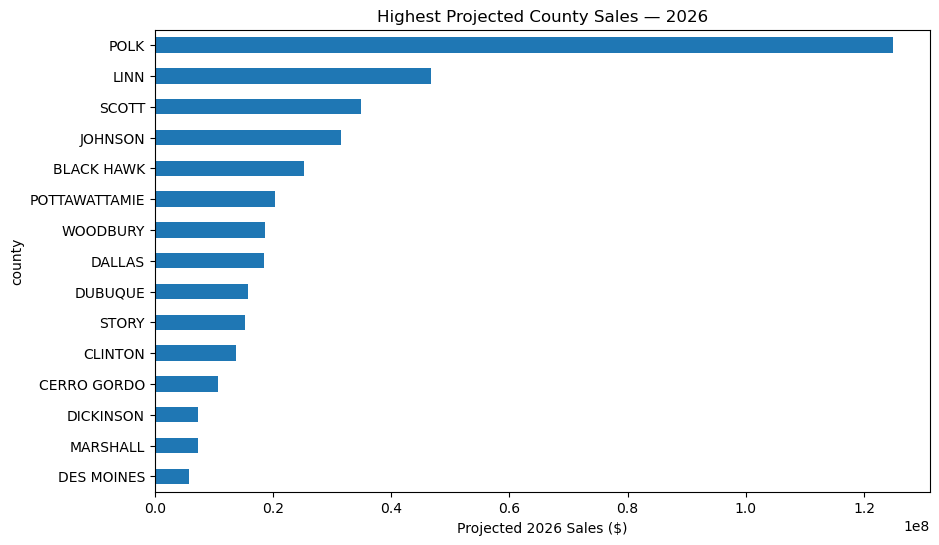

In [68]:
county_forecast.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Projected 2026 Sales ($)")
plt.title("Highest Projected County Sales — 2026")

plt.show()

In [69]:
county_year_sales = (
    booze[
        booze["year"].isin(
            [2023, 2024, 2025]
        )
    ]
    .groupby(
        ["county", "year"]
    )["sales_dollars"]
    .sum()
    .reset_index()
)

In [70]:
county_growth = (
    county_year_sales
    .pivot(
        index="county",
        columns="year",
        values="sales_dollars"
    )
    .reset_index()
)

county_growth.head()

year,county,2023,2024,2025
0,ADAIR,536218.11,716578.90,630118.95
1,ADAMS,271461.11,370465.04,347322.94
2,ALLAMAKEE,1183750.96,1346080.52,1370716.28
3,APPANOOSE,1133882.79,1392862.46,1413983.26
4,AUDUBON,265942.56,312552.97,294138.25


In [71]:
county_growth[
    "growth_2023_2024"
] = (
    (
        county_growth[2024]
        - county_growth[2023]
    )
    / county_growth[2023]
    * 100
)

county_growth[
    "growth_2024_2025"
] = (
    (
        county_growth[2025]
        - county_growth[2024]
    )
    / county_growth[2024]
    * 100
)

In [72]:
county_growth[
    "average_recent_growth"
] = (
    county_growth[
        [
            "growth_2023_2024",
            "growth_2024_2025"
        ]
    ]
    .mean(axis=1)
)

In [73]:
county_growth.sort_values(
    "average_recent_growth",
    ascending=False
).head(15)

year,county,2023,2024,2025,growth_2023_2024,growth_2024_2025,average_recent_growth
70,NONE,126366.55,84139.16,311680.83,-33.416588,270.434920,118.509166
43,HENRY,1659527.30,2091337.23,2546489.61,26.020056,21.763701,23.891878
35,FREMONT,220977.34,307214.20,311934.79,39.025205,1.536579,20.280892
9,BUCHANAN,1489324.97,2168163.82,2054120.00,45.580304,-5.259926,20.160189
38,GUTHRIE,679563.04,852708.55,962491.83,25.478947,12.874655,19.176801
63,MARSHALL,5077559.52,6411404.33,7040868.45,26.269408,9.817882,18.043645
98,WORTH,530380.42,711288.99,714523.78,34.109210,0.454779,17.281994
36,GREENE,729278.52,856793.14,996631.19,17.485037,16.321098,16.903068
86,TAMA,968931.57,1412177.58,1232946.87,45.745853,-12.691797,16.527028
50,JEFFERSON,1427562.55,1804078.80,1913469.60,26.374764,6.063527,16.219145


In [74]:
county_growth[
    "sales_2025"
] = county_growth[2025]

In [75]:
median_sales = (
    county_growth["sales_2025"].median()
)

growth_opportunities = (
    county_growth[
        county_growth["sales_2025"]
        >= median_sales
    ]
    .sort_values(
        "average_recent_growth",
        ascending=False
    )
)

growth_opportunities[
    [
        "county",
        "sales_2025",
        "growth_2023_2024",
        "growth_2024_2025",
        "average_recent_growth"
    ]
].head(15)

year,county,sales_2025,growth_2023_2024,growth_2024_2025,average_recent_growth
43,HENRY,2546489.61,26.020056,21.763701,23.891878
9,BUCHANAN,2054120.00,45.580304,-5.259926,20.160189
63,MARSHALL,7040868.45,26.269408,9.817882,18.043645
50,JEFFERSON,1913469.60,26.374764,6.063527,16.219145
32,FAYETTE,2077403.40,31.798182,-3.021619,14.388281
84,SIOUX,3290127.83,35.676544,-7.866972,13.904786
13,CARROLL,4065808.91,25.600934,2.002419,13.801676
96,WINNESHIEK,2699100.26,19.114732,8.159338,13.637035
23,CRAWFORD,2235961.86,32.088384,-5.031818,13.528283
27,DELAWARE,1810884.02,23.961852,2.672276,13.317064


In [76]:
population_by_year = (
    booze
    .groupby("year")["county_population"]
    .apply(
        lambda x: x.notna().sum()
    )
)

population_by_year

year
2012    1187
2013    1186
2014    1183
2015    1186
2016    1187
2017    1188
2018    1188
2019    1184
2020    1186
2021    1188
2022    1188
2023    1188
2024    1188
2025       0
2026       0
Name: county_population, dtype: int64

In [77]:
market_2024 = (
    booze[
        booze["year"] == 2024
    ]
    .groupby("county")
    .agg(
        sales_dollars=("sales_dollars", "sum"),
        population=("county_population", "max")
    )
    .reset_index()
)

In [78]:
market_2024[
    "sales_per_capita"
] = (
    market_2024["sales_dollars"]
    / market_2024["population"]
)

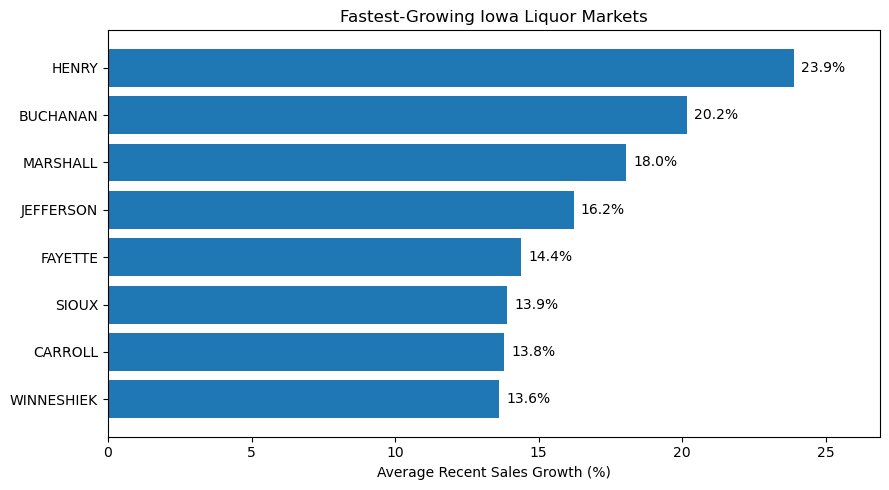

In [90]:
# Get top 8 counties by recent growth
top_growth = (
    growth_opportunities
    .sort_values("average_recent_growth", ascending=False)
    .head(8)
    .sort_values("average_recent_growth", ascending=True)
)

plt.figure(figsize=(9, 5))

plt.barh(
    top_growth["county"],
    top_growth["average_recent_growth"]
)

plt.xlabel("Average Recent Sales Growth (%)")
plt.ylabel("")
plt.title("Fastest-Growing Iowa Liquor Markets")

# Add percentage labels
for i, value in enumerate(top_growth["average_recent_growth"]):
    plt.text(
        value + 0.25,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(0, top_growth["average_recent_growth"].max() + 3)

plt.tight_layout()
plt.show()

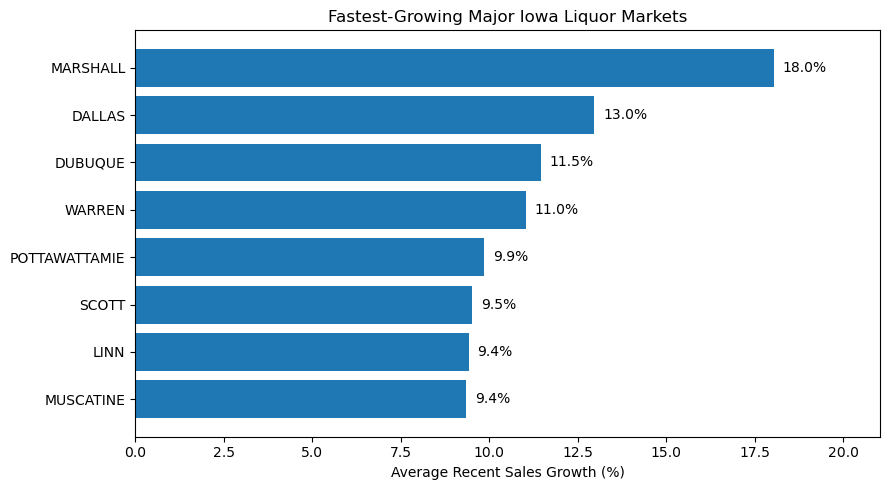

In [91]:
# Only consider counties with at least $5M in 2025 sales
meaningful_markets = growth_opportunities[
    growth_opportunities["sales_2025"] >= 5_000_000
]

# Top 8 fastest-growing meaningful markets
top_growth = (
    meaningful_markets
    .sort_values("average_recent_growth", ascending=False)
    .head(8)
    .sort_values("average_recent_growth", ascending=True)
)

plt.figure(figsize=(9, 5))

plt.barh(
    top_growth["county"],
    top_growth["average_recent_growth"]
)

plt.xlabel("Average Recent Sales Growth (%)")
plt.ylabel("")
plt.title("Fastest-Growing Major Iowa Liquor Markets")

for i, value in enumerate(top_growth["average_recent_growth"]):
    plt.text(
        value + 0.25,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(0, top_growth["average_recent_growth"].max() + 3)

plt.tight_layout()
plt.show()

In [79]:
market_2024.sort_values(
    "sales_per_capita",
    ascending=False
)[
    [
        "county",
        "sales_dollars",
        "population",
        "sales_per_capita"
    ]
].head(15)

,county,sales_dollars,population,sales_per_capita
44,HOWARD,1.247014e+06,3105.0,401.614860
29,DICKINSON,6.907708e+06,18158.0,380.422267
22,CLINTON,1.317626e+07,46015.0,286.347040
16,CERRO GORDO,1.046897e+07,42493.0,246.369399
77,POLK,1.201590e+08,516185.0,232.782864
78,POTTAWATTAMIE,1.917922e+07,93529.0,205.061773
6,BLACK HAWK,2.657223e+07,132348.0,200.775493
13,CARROLL,3.985993e+06,20407.0,195.324773
82,SCOTT,3.356965e+07,175601.0,191.170066
56,LINN,4.404905e+07,231762.0,190.061566


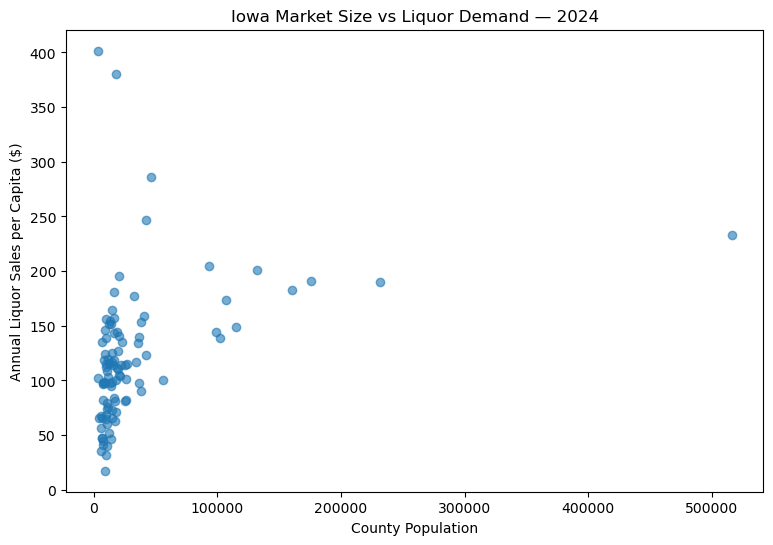

In [80]:
plt.figure(figsize=(9, 6))

plt.scatter(
    market_2024["population"],
    market_2024["sales_per_capita"],
    alpha=0.6
)

plt.xlabel("County Population")
plt.ylabel("Annual Liquor Sales per Capita ($)")
plt.title("Iowa Market Size vs Liquor Demand — 2024")

plt.show()

In [86]:
print("Actual 2025 sales:")
print(test_final["sales_dollars"].sum())

print("\nOur model predicted 2025 sales:")
print(test_final["predicted_sales"].sum())

print("\nBaseline predicted 2025 sales:")
print(test_final["sales_lag_12"].sum())

Actual 2025 sales:
523110953.68999994

Our model predicted 2025 sales:
561834018.3554058

Baseline predicted 2025 sales:
524696310.21000004


In [81]:
print("=" * 60)
print("BOOZE R' US — FINAL RESULTS")
print("=" * 60)

print()

print("FORECAST PERFORMANCE")
print(
    f"2025 test RMSE: "
    f"${final_test_rmse:,.0f}"
)

print(
    f"2025 test MAE: "
    f"${final_test_mae:,.0f}"
)

print(
    f"RMSE improvement over previous-year baseline: "
    f"{rmse_improvement:.1f}%"
)

print()

print("2026 FORECAST")
print(
    f"Projected statewide sales: "
    f"${projected_2026_sales:,.0f}"
)

print(
    f"Projected growth vs 2025: "
    f"{projected_growth:.1f}%"
)

print()

print("TOP PROJECTED MONTHS")

print(
    forecast_monthly[
        [
            "month_name",
            "predicted_sales"
        ]
    ]
    .sort_values(
        "predicted_sales",
        ascending=False
    )
    .head(3)
    .to_string(index=False)
)

print()

print("TOP PROJECTED COUNTIES")

print(
    county_forecast
    .head(5)
    .to_string()
)

print()

print("HIGH-GROWTH, MEANINGFUL-SIZE MARKETS")

print(
    growth_opportunities[
        [
            "county",
            "sales_2025",
            "average_recent_growth"
        ]
    ]
    .head(5)
    .to_string(index=False)
)

BOOZE R' US — FINAL RESULTS

FORECAST PERFORMANCE
2025 test RMSE: $546,059
2025 test MAE: $151,387
RMSE improvement over previous-year baseline: 11.4%

2026 FORECAST
Projected statewide sales: $548,898,348
Projected growth vs 2025: 4.9%

TOP PROJECTED MONTHS
month_name  predicted_sales
   October     7.762136e+07
 September     6.134266e+07
  November     6.056408e+07

TOP PROJECTED COUNTIES
county
POLK          1.248824e+08
LINN          4.676767e+07
SCOTT         3.486748e+07
JOHNSON       3.155690e+07
BLACK HAWK    2.532886e+07

HIGH-GROWTH, MEANINGFUL-SIZE MARKETS
   county  sales_2025  average_recent_growth
    HENRY  2546489.61              23.891878
 BUCHANAN  2054120.00              20.160189
 MARSHALL  7040868.45              18.043645
JEFFERSON  1913469.60              16.219145
  FAYETTE  2077403.40              14.388281


In [82]:
historical_monthly = (
    booze[
        booze["year"] <= 2025
    ]
    .groupby(["year", "month"])["sales_dollars"]
    .sum()
    .reset_index()
)

historical_monthly[
    historical_monthly["month"].isin([9, 10, 11])
].tail(15)

,year,month,sales_dollars
116,2021,9,35837061.02
117,2021,10,38085762.36
118,2021,11,55978576.40
128,2022,9,36622693.61
129,2022,10,63842478.58
130,2022,11,75026877.26
140,2023,9,35096963.96
141,2023,10,40281758.90
142,2023,11,39289673.49
152,2024,9,34410490.22


In [83]:
final_coefficients.sort_values(
    "coefficient",
    ascending=False
)

,feature,coefficient
12,month_12,149749.494794
10,month_10,130493.137063
11,month_11,119143.314219
5,month_5,103404.592602
3,month_3,103319.566807
2,month_2,101227.707264
8,month_8,98861.861742
4,month_4,97765.484972
6,month_6,97221.869370
9,month_9,87804.275542


In [84]:
yearly_sales = (
    booze
    .groupby("year")["sales_dollars"]
    .sum()
    .reset_index()
)

yearly_sales

,year,sales_dollars
0,2012,2.552033e+08
1,2013,2.581038e+08
2,2014,2.705877e+08
3,2015,2.843286e+08
4,2016,2.994476e+08
5,2017,3.145300e+08
6,2018,3.342168e+08
7,2019,3.492203e+08
8,2020,4.942242e+08
9,2021,4.883849e+08


In [85]:
monthly_2025 = (
    booze[
        booze["year"] == 2025
    ]
    .groupby("month")["sales_dollars"]
    .sum()
    .reset_index()
)

monthly_2025

,month,sales_dollars
0,1,31111677.66
1,2,31308695.75
2,3,33518798.61
3,4,35499986.35
4,5,35589683.49
5,6,35946281.01
6,7,36094242.39
7,8,52138234.57
8,9,70315545.46
9,10,80094271.40


END OF BOOZE, START OF DEAD

In [44]:
#For dead, drop 2025 and 2026 data that has no population data, keep for booze
dead_monthly = df_main[
    df_main["county_population"].notna()
].copy()

In [45]:
dead = (
    dead_monthly
    .groupby(
        ["county", "year"],
        as_index=False
    )
    .agg(
        sales_liters=(
            "sales_liters",
            "sum"
        ),

        sales_dollars=(
            "sales_dollars",
            "sum"
        ),

        sales_bottles=(
            "sales_bottles",
            "sum"
        ),

        county_population=(
            "county_population",
            "first"
        ),

        avg_alcohol_level_g210L=(
            "avg_alcohol_level_g210L",
            "first"
        ),

        num_tests=(
            "num_tests",
            "first"
        )
    )
)

In [46]:
dead["liters_per_capita"] = (
    dead["sales_liters"]
    / dead["county_population"]
)

In [47]:
dead.head()

,county,year,sales_liters,sales_dollars,sales_bottles,county_population,avg_alcohol_level_g210L,num_tests,liters_per_capita
0,ADAIR,2012,33297.02,413691.48,34894,7468.0,0.124,24.0,4.458626
1,ADAIR,2013,31159.97,378584.26,32112,7387.0,0.126,21.0,4.218217
2,ADAIR,2014,33383.60,413071.07,34466,7368.0,0.159,29.0,4.530890
3,ADAIR,2015,33957.85,424750.82,35049,7145.0,0.133,25.0,4.752673
4,ADAIR,2016,34773.16,444516.75,36071,7005.0,0.142,28.0,4.964049


In [ ]:
dead["liters_per_capita"].describe()

,liters_per_capita
count,1287.000000
mean,5.521088
std,3.047866
min,0.116174
25%,3.655524
50%,5.132168
75%,6.826776
max,31.400302


In [ ]:
dead.sort_values(
    "liters_per_capita",
    ascending=False
)[
    [
        "county",
        "year",
        "sales_liters",
        "county_population",
        "liters_per_capita"
    ]
].head(20)

,county,year,sales_liters,county_population,liters_per_capita
581,HOWARD,2021,99727.36,3176.0,31.400302
582,HOWARD,2022,94057.58,3163.0,29.736826
584,HOWARD,2024,75151.99,3105.0,24.203539
386,DICKINSON,2021,400141.76,17876.0,22.384301
387,DICKINSON,2022,401579.30,18052.0,22.245696
385,DICKINSON,2020,386052.82,17703.0,21.807198
583,HOWARD,2023,67020.40,3140.0,21.344076
389,DICKINSON,2024,382911.68,18158.0,21.087767
388,DICKINSON,2023,358413.79,18087.0,19.816099
384,DICKINSON,2019,317827.83,17258.0,18.416261


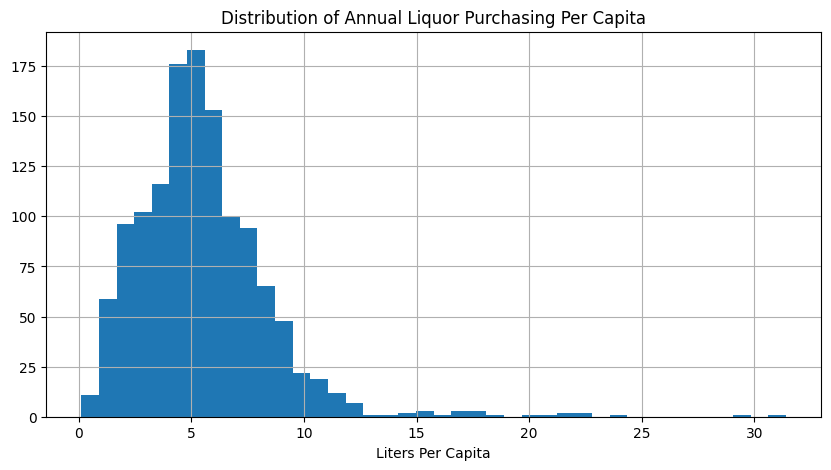

In [ ]:
dead["liters_per_capita"].hist(
    bins=40,
    figsize=(10, 5)
)

plt.xlabel("Liters Per Capita")
plt.title(
    "Distribution of Annual Liquor Purchasing Per Capita"
)

plt.show()

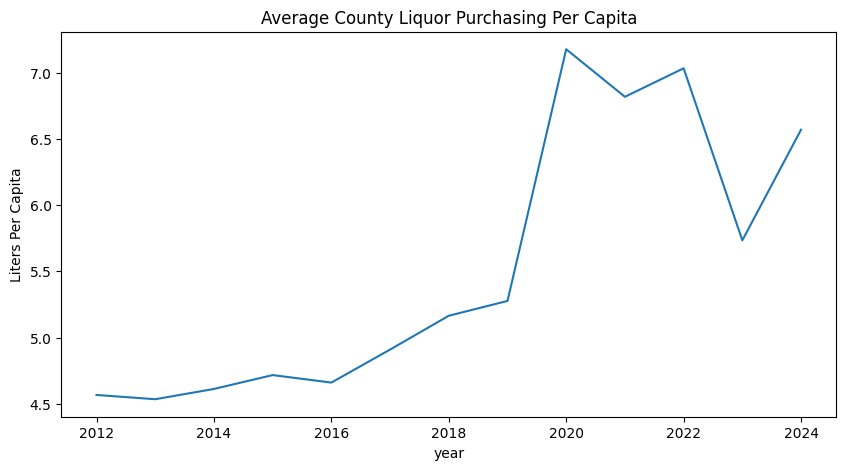

In [ ]:
yearly_dead = (
    dead.groupby("year")["liters_per_capita"]
        .mean()
)

yearly_dead.plot(
    figsize=(10, 5),
    title="Average County Liquor Purchasing Per Capita"
)

plt.ylabel("Liters Per Capita")
plt.show()

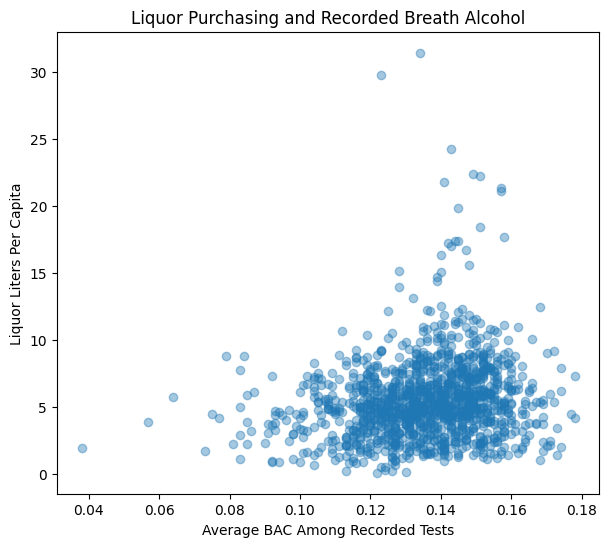

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    dead["avg_alcohol_level_g210L"],
    dead["liters_per_capita"],
    alpha=0.4
)

plt.xlabel("Average BAC Among Recorded Tests")
plt.ylabel("Liquor Liters Per Capita")
plt.title("Liquor Purchasing and Recorded Breath Alcohol")

plt.show()

In [ ]:
dead[
    [
        "liters_per_capita",
        "avg_alcohol_level_g210L",
        "num_tests",
        "county_population"
    ]
].corr()

,liters_per_capita,avg_alcohol_level_g210L,num_tests,county_population
liters_per_capita,1.000000,0.176509,0.318397,0.314014
avg_alcohol_level_g210L,0.176509,1.000000,0.066375,0.120111
num_tests,0.318397,0.066375,1.000000,0.916127
county_population,0.314014,0.120111,0.916127,1.000000


In [ ]:
dead["tests_per_1000"] = (
    dead["num_tests"]
    / dead["county_population"]
    * 1000
)
dead["years_since_start"] = (
    dead["year"] - dead["year"].min()
)

In [ ]:
#Log population to account for large variance in populations

dead["log_population"] = np.log(
    dead["county_population"]
)

In [ ]:
dead_train = dead[
    dead["year"] <= 2022
].copy()

dead_val = dead[
    dead["year"].isin([2023, 2024])
].copy()

In [ ]:
yearly_dead = (
    dead.groupby("year")["liters_per_capita"]
        .mean()
)

yearly_dead.plot(
    figsize=(10, 5),
    color="steelblue",
    title="Average County Liquor Purchasing Per Capita"
)

plt.ylabel("Liters Per Capita")
plt.show()

NameError: name 'dead' is not defined

In [ ]:
#Model 2: Time + BAC

dead_features2 = [
    "years_since_start",
    "avg_alcohol_level_g210L"
]

dead_model2 = LinearRegression()

dead_model2.fit(
    dead_train[dead_features2],
    dead_train["liters_per_capita"]
)

dead_pred2 = dead_model2.predict(
    dead_val[dead_features2]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred2
    )
)

pd.Series(
    dead_model2.coef_,
    index=dead_features2
)

RMSE: 3.4372222580542604


,0
years_since_start,0.275987
avg_alcohol_level_g210L,31.400162


In [ ]:
#Model 3: adding test frequency

dead_features3 = [
    "years_since_start",
    "avg_alcohol_level_g210L",
    "tests_per_1000"
]

dead_model3 = LinearRegression()

dead_model3.fit(
    dead_train[dead_features3],
    dead_train["liters_per_capita"]
)

dead_pred3 = dead_model3.predict(
    dead_val[dead_features3]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred3
    )
)

print(
    pd.Series(
        dead_model3.coef_,
        index=dead_features3
    )
)

RMSE: 3.353584162970485
years_since_start           0.374619
avg_alcohol_level_g210L    38.351779
tests_per_1000              0.512339
dtype: float64


In [ ]:
dead_features4 = [
    "years_since_start",
    "avg_alcohol_level_g210L",
    "tests_per_1000",
    "log_population"
]

dead_model4 = LinearRegression()

dead_model4.fit(
    dead_train[dead_features4],
    dead_train["liters_per_capita"]
)

dead_pred4 = dead_model4.predict(
    dead_val[dead_features4]
)

print(
    "RMSE:",
    rmse(
        dead_val["liters_per_capita"],
        dead_pred4
    )
)

print(
    pd.Series(
        dead_model4.coef_,
        index=dead_features4
    )
)

RMSE: 3.187733398278088
years_since_start           0.371070
avg_alcohol_level_g210L    25.654618
tests_per_1000              0.476603
log_population              1.251081
dtype: float64


In [ ]:
results_dead = pd.DataFrame({
    "Model": [
        "Time trend",
        "Time + BAC",
        "Time + BAC + Tests",
        "Time + BAC + Tests + Population"
    ],

    "RMSE": [
        rmse(
            dead_val["liters_per_capita"],
            dead_pred1
        ),
        rmse(
            dead_val["liters_per_capita"],
            dead_pred2
        ),
        rmse(
            dead_val["liters_per_capita"],
            dead_pred3
        ),
        rmse(
            dead_val["liters_per_capita"],
            dead_pred4
        )
    ]
})

results_dead.sort_values("RMSE")

,Model,RMSE
3,Time + BAC + Tests + Population,3.187733
2,Time + BAC + Tests,3.353584
1,Time + BAC,3.437222
0,Time trend,3.445266
